In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import suncalc

import dask.dataframe as dd
from pathlib import Path
from tqdm import tqdm
import re
import pytz

import datetime as dt

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from matplotlib.lines import Line2D

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/activity")

In [3]:
import subsampling as ss
import activity_assembly as actvt
import bout.assembly as bt
import comparison.data_assembly as comp
import comparison.plot as complot
from core import SITE_NAMES

from cli import get_file_paths
import plot
import pipeline

In [4]:
avail = np.arange(0, 180, 2) + 2
reset_3 = avail[np.where((3*60 % avail) == 0)[0]]
reset_4 = avail[np.where((4*60 % avail) == 0)[0]]
reset_6 = avail[np.where((6*60 % avail) == 0)[0]]
reset_12 = avail[np.where((12*60 % avail) == 0)[0]]
reset_24 = avail[np.where((24*60 % avail) == 0)[0]]

In [5]:
dt_starts = {'Carp high':dt.datetime(2022, 7, 15, 3, 0, 0),
           'Telephone high':dt.datetime(2022, 8, 19, 3, 0, 0)}
dt_ends = {'Carp high':dt.datetime(2022, 10, 17, 13, 0, 0),
           'Telephone high':dt.datetime(2022, 9, 19, 13, 0, 0)}
high_activity_types = {'Carp':'LF', 'Telephone':'HF'}

In [6]:
step = 1/10
step_by = np.arange(step, 1, step)
# step_by = step_by[step_by>=(1/6)]
step_by

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [7]:
step = 1/6
step_by = np.arange(0, (3/6)+step, step)
step_by = step_by[step_by>=(1/6)][::-1]
step_by

array([0.5       , 0.33333333, 0.16666667])

In [8]:
cycle_lengths = [30, 10, 6]
percent_ons = step_by
data_params = dict()
data_params["cycle_lengths"] = cycle_lengths
data_params["percent_ons"] = percent_ons
dc_tags = ss.get_list_of_dc_tags(cycle_lengths, percent_ons)
dc_tags

['30of30',
 '15of30',
 '10of30',
 '5of30',
 '5of10',
 '3of10',
 '2of10',
 '3of6',
 '2of6',
 '1of6']

In [9]:
def get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb):
    points_dc = pd.DataFrame(plt_dcmetr.values, columns=['values'], index=plt_dcmetr.index)
    points_c = pd.DataFrame(plt_cmetr.values, columns=['values'], index=plt_cmetr.index)
    points_c = points_c[points_c!=0].dropna()
    points_dc = points_dc.loc[points_c.index]
    total_num_points = points_dc.shape[0]

    axis = 1
    within_bounds = ((points_dc.values<=points_c.values*(axis+(upb*p)))&(points_dc.values>=points_c.values*(axis-p)))
    num_points_in_bounds = np.sum(within_bounds.astype(int), axis=0)
    percent_points_in_bounds = num_points_in_bounds / total_num_points
    # all_points_bound = p[percent_points_in_bounds==1][0]
    # test_true_100_at_factor(points_dc, points_c, all_points_bound)

    return percent_points_in_bounds

def test_true_100_at_factor(points_dc, points_c, p):
    test_dc = points_dc[points_dc!=0].dropna()
    test_c = points_c.loc[test_dc.index]
    filt_dc = (test_dc.values>test_c.values*(1+p))|(test_dc.values<test_c.values*(1-p))
    assert filt_dc.all()==False
    
def plot_percent_within_bounds_curve_for_metric(ax, plt_dcmetr, plt_cmetr, data_params):
    frac = float(re.findall(r"(\d.\d+)", plt_dcmetr.columns[0])[0])
    p = np.arange(0, 10, 0.01) + 1e-14
    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]
    
    if data_params['metric_tag']=='call_rate':
        thresh = 50
        col = 'red'
        mtag = 'CR'
    elif data_params['metric_tag']=='activity_index':
        thresh = 50
        col = 'royalblue'
        mtag = 'AI'
    else:
        thresh = 50
        col = 'green'
        mtag = 'BTP'

    high_cmetr = plt_cmetr[plt_cmetr>=thresh].dropna()
    low_cmetr = plt_cmetr[plt_cmetr<thresh].dropna()
    high_dcmetr = plt_dcmetr.loc[high_cmetr.index].copy()
    low_dcmetr = plt_dcmetr.loc[low_cmetr.index].copy()

    percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, 1.0)
    ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle='solid', linewidth=3, alpha=0.4)
    
    percent_points_in_bounds = get_percent_points_in_bounds_log(high_dcmetr, high_cmetr, p, 1.0)
    ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle='solid', linewidth=3, alpha=0.8)
    
    percent_points_in_bounds = get_percent_points_in_bounds_log(low_dcmetr, low_cmetr, p, 1.0)
    ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle='dashed', linewidth=3, alpha=0.8)


    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

In [10]:
def plot_indiv_dc_control_comp_over_cycle_linear_scale(ax, single_col_dc_metr1, single_col_c_metr, data_params):
    single_col_dc_metr1.index = pd.DatetimeIndex(single_col_dc_metr1.index)
    dc_metr1 = pd.pivot_table(single_col_dc_metr1, index=(single_col_dc_metr1.index.time), 
                        columns=single_col_dc_metr1.index.date, 
                        values=single_col_dc_metr1.columns[0])
    single_col_c_metr.index = pd.DatetimeIndex(single_col_c_metr.index)
    paired_col_c_metr = single_col_c_metr[(~single_col_dc_metr1.isna()).values]
    c_metr = pd.pivot_table(paired_col_c_metr, index=(paired_col_c_metr.index.time), 
                    columns=paired_col_c_metr.index.date, 
                    values=paired_col_c_metr.columns[0])
    ax.grid(which='both')
    if data_params['metric_tag']=='call_rate':
        col = 'red'
        units = 'calls/min'
    elif data_params['metric_tag']=='activity_index':
        col = 'royalblue'
        units = '%'
    else:
        col = 'green'
        units = '%'
    frac = float(re.findall(r"\d.\d+", single_col_dc_metr1.columns[0])[0])
    c_metr_max = c_metr.max().max()
    ax.plot([0, 100*c_metr_max], [0, 100*c_metr_max], linestyle='dashed', color='k', label='line-of-unity')
    
    ax.scatter(c_metr, dc_metr1, color=col, edgecolors='k', s=80, alpha=0.8)
    ax.set_xlabel(f'True values ({units})')
    ax.set_ylabel(f'Reduced estimate ({units})')
    upper_lim = 400
    if (data_params['metric_tag'] == 'call_rate'):
        ax.set_xlim(0, upper_lim)
        ax.set_ylim(0, upper_lim)
    else:
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_xticks(np.arange(0, 110, 20))
        ax.set_yticks(np.arange(0, 110, 20))

In [11]:
def get_associated_metric_for_cont_column(metric_for_scheme, cont_column):
    merged_indices = pd.DatetimeIndex(pd.concat([pd.Series(metric_for_scheme.index), pd.Series(cont_column.index)]).sort_values().unique())
    metric_for_scheme_for_comparison = metric_for_scheme.reindex(merged_indices, fill_value=0)
    cont_column = cont_column.reindex(merged_indices, fill_value=0)
    comp.does_reindexed_match_original_at_original_indices(metric_for_scheme_for_comparison, metric_for_scheme)
    comp.do_calls_exist_in_reindexed_version(metric_for_scheme_for_comparison)

    return metric_for_scheme_for_comparison

In [12]:
site_keys = ['Carp']
type_keys = ['LF']
data_params["dc_tags"] = dc_tags
data_params['cur_dc_tag'] = '30of30'
data_params['recording_start'] = '03:00'
data_params['recording_end'] = '13:00'
data_params['assembly_type'] = 'kmeans'
site_key = site_keys[0]
type_key = type_keys[0]

type_key = high_activity_types[site_key]
actvt_key = 'high'
data_params['start'] = dt_starts[f'{site_key} {actvt_key}']
data_params['end'] = dt_ends[f'{site_key} {actvt_key}']
data_params['P'] = 0.4

In [13]:
def get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb):
    points_dc = pd.DataFrame(plt_dcmetr.values, columns=['values'], index=plt_dcmetr.index)
    points_c = pd.DataFrame(plt_cmetr.values, columns=['values'], index=plt_cmetr.index)
    points_c = points_c[points_c!=0].dropna()
    points_dc = points_dc.loc[points_c.index]
    total_num_points = points_dc.shape[0]

    axis = 1
    within_bounds = ((points_dc.values<=points_c.values*(axis+(upb*p)))&(points_dc.values>=points_c.values*(axis-p)))
    num_points_in_bounds = np.sum(within_bounds.astype(int), axis=0)
    percent_points_in_bounds = num_points_in_bounds / total_num_points
    # all_points_bound = p[percent_points_in_bounds==1][0]
    # test_true_100_at_factor(points_dc, points_c, all_points_bound)

    return percent_points_in_bounds

def test_true_100_at_factor(points_dc, points_c, p):
    test_dc = points_dc[points_dc!=0].dropna()
    test_c = points_c.loc[test_dc.index]
    filt_dc = (test_dc.values>test_c.values*(1+p))|(test_dc.values<test_c.values*(1-p))
    assert filt_dc.all()==False
    
def plot_percent_within_bounds_curve_for_metric(ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level='all'):
    frac = float(re.findall(r"(\d.\d+)", plt_dcmetr.columns[0])[0])
    p = np.arange(0, 10, 0.01) + 1e-14
    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]
    
    if data_params['metric_tag']=='call_rate':
        thresh = 50
        col = 'red'
        mtag = 'CR'
    elif data_params['metric_tag']=='activity_index':
        thresh = 50
        col = 'royalblue'
        mtag = 'AI'
    else:
        thresh = 50
        col = 'green'
        mtag = 'BTP'

    high_cmetr = plt_cmetr[plt_cmetr>=thresh].dropna()
    low_cmetr = plt_cmetr[plt_cmetr<thresh].dropna()
    high_dcmetr = plt_dcmetr.loc[high_cmetr.index].copy()
    low_dcmetr = plt_dcmetr.loc[low_cmetr.index].copy()

    if activity_level=='all':
        percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, 1.0)
        ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle=plt_linestyle, linewidth=3, alpha=0.8)
    
    if activity_level=='high':
        percent_points_in_bounds = get_percent_points_in_bounds_log(high_dcmetr, high_cmetr, p, 1.0)
        ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle=plt_linestyle, linewidth=3, alpha=0.8)
    
    if activity_level=='low':
        percent_points_in_bounds = get_percent_points_in_bounds_log(low_dcmetr, low_cmetr, p, 1.0)
        ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle=plt_linestyle, linewidth=3, alpha=0.8)

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

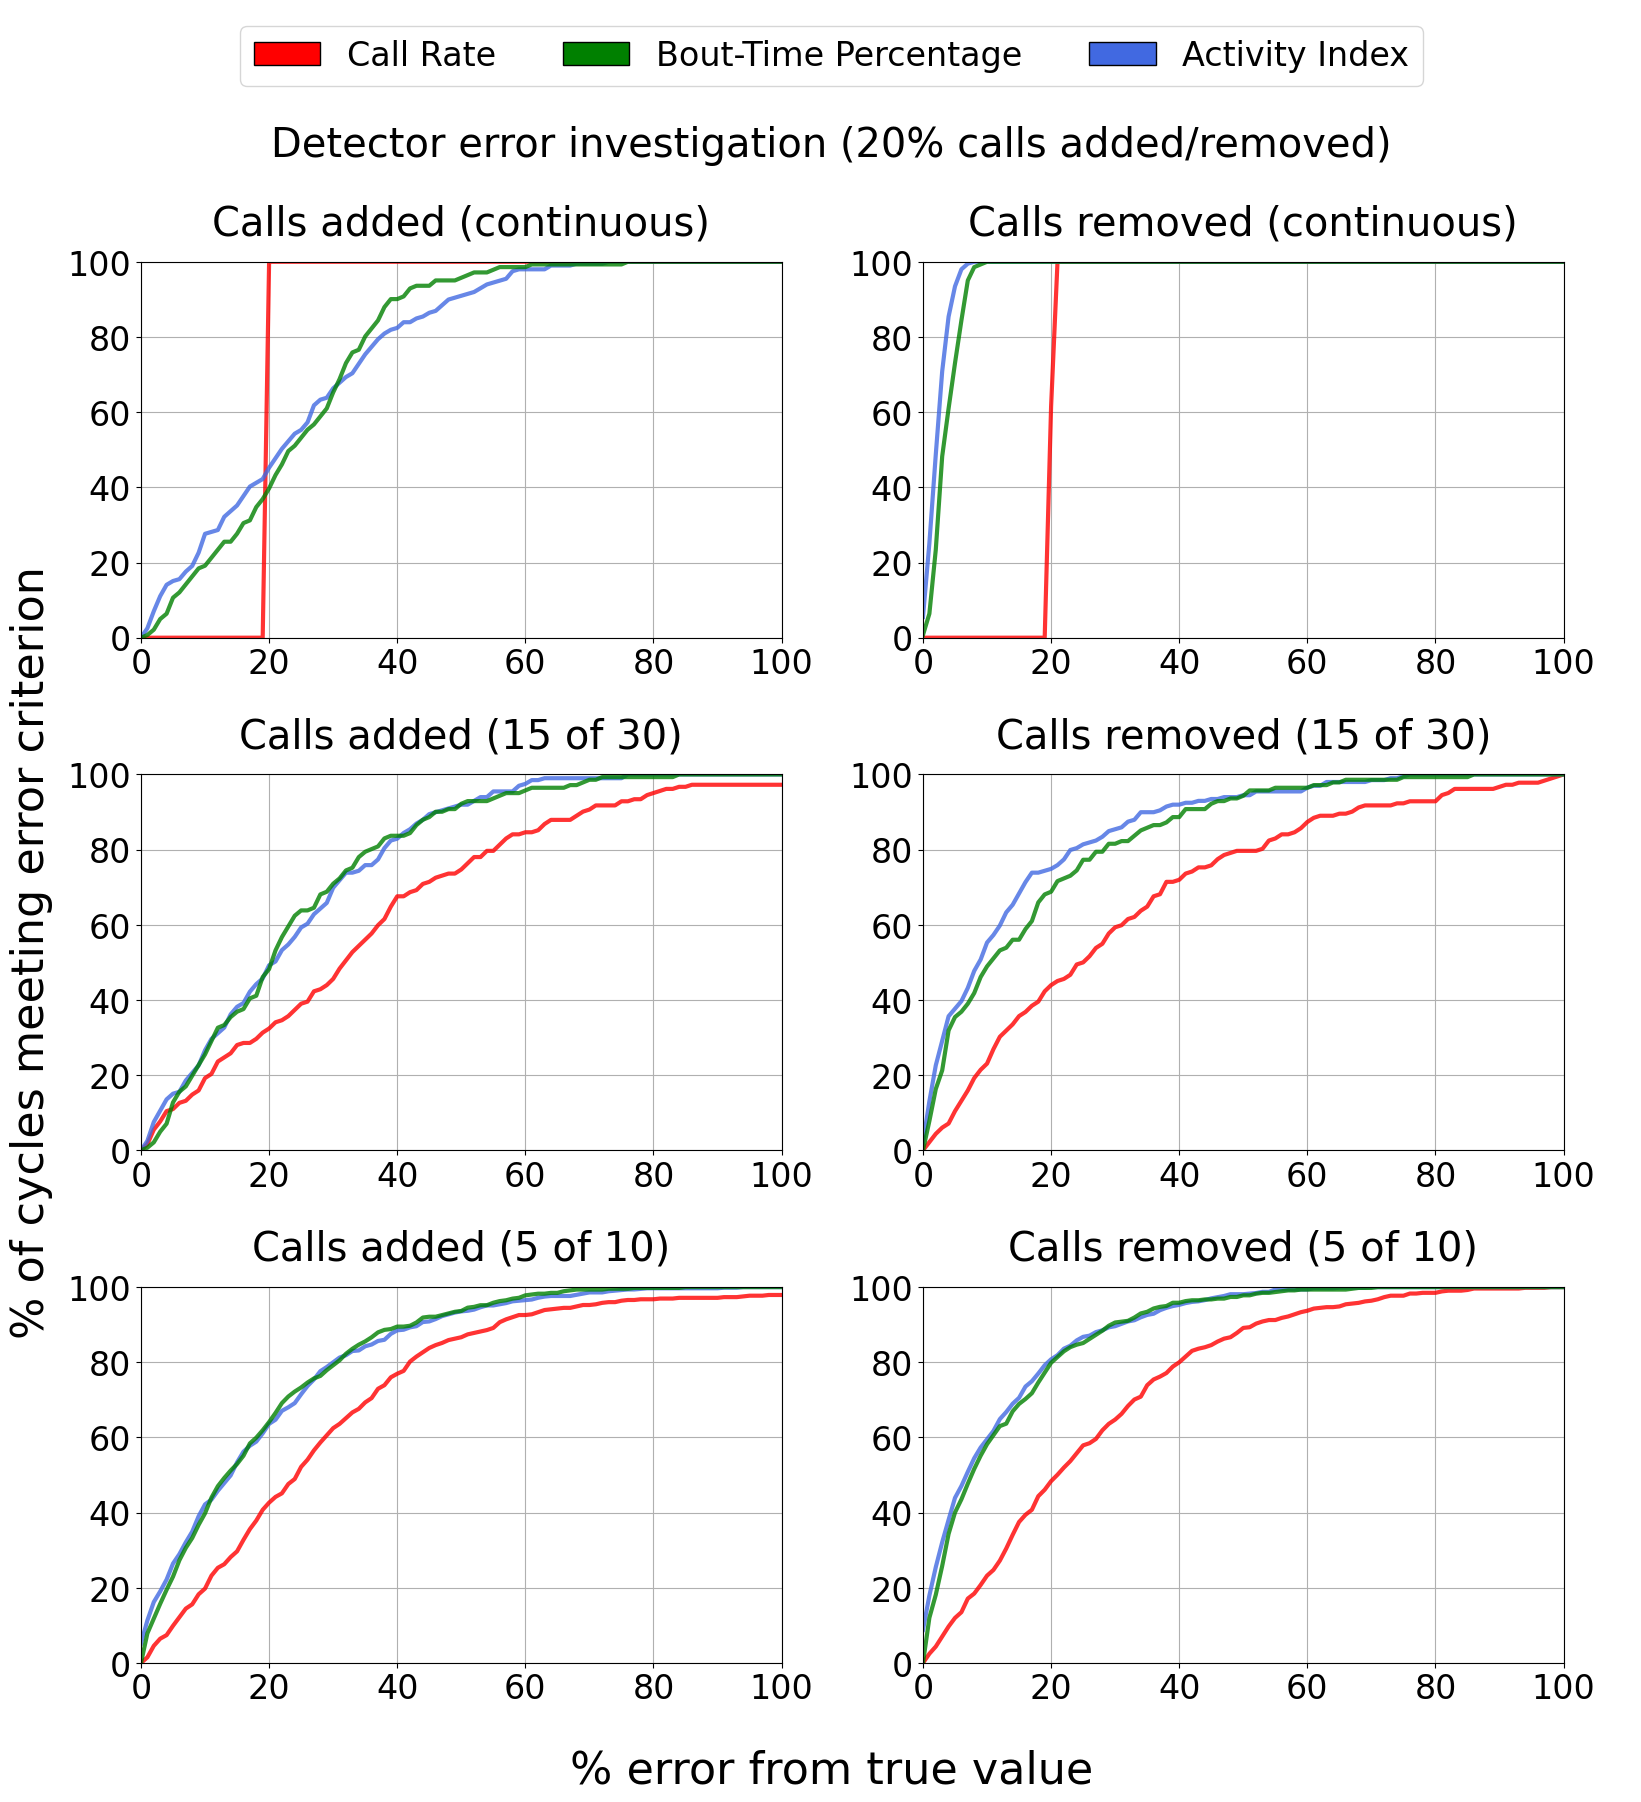

In [17]:
activity_level = 'high'
dc_tag = '30of30'
time_on = (dc_tag.split('of')[0])
cycle_length = (dc_tag.split('of')[-1])
cont_tag = f'{cycle_length}of{cycle_length}'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

fig, ax = plt.subplots(3, 2, figsize=(16, 16.5), constrained_layout=True)
plt.rcParams.update({'font.size':24})
fig.suptitle(f'Detector error investigation (20% calls added/removed)')


i=0
frac = 0.2
plt_linestyle='solid'
cur_ax = ax[i,0]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'Calls added (continuous)', y=1.05)
cur_ax.grid(which='both')

frac = 0.8
cur_ax = ax[i,1]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'Calls removed (continuous)', y=1.05)
cur_ax.grid(which='both')

dc_tag = '15of30'
time_on = (dc_tag.split('of')[0])
cycle_length = (dc_tag.split('of')[-1])
cont_tag = f'{cycle_length}of{cycle_length}'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

i=1
frac = 0.2
plt_linestyle='solid'
cur_ax = ax[i,0]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'Calls added ({time_on} of {cycle_length})', y=1.05)
cur_ax.grid(which='both')

frac = 0.8
cur_ax = ax[i,1]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'Calls removed ({time_on} of {cycle_length})', y=1.05)
cur_ax.grid(which='both')

dc_tag = '5of10'
time_on = (dc_tag.split('of')[0])
cycle_length = (dc_tag.split('of')[-1])
cont_tag = f'{cycle_length}of{cycle_length}'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

i=2
frac = 0.2
plt_linestyle='solid'
cur_ax = ax[i,0]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'Calls added ({time_on} of {cycle_length})', y=1.05)
cur_ax.grid(which='both')

frac = 0.8
cur_ax = ax[i,1]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'Calls removed ({time_on} of {cycle_length})', y=1.05)
cur_ax.grid(which='both')


fig.text(0, 0.25, '% of cycles meeting error criterion', ha='center', rotation='vertical', fontsize=plt.rcParams['font.size']+8)
fig.text(0.5, -0.025, '% error from true value', ha='center', fontsize=plt.rcParams['font.size']+8)
fig.tight_layout()

# Create legend patches
CR_patch = patches.Patch(facecolor='red', edgecolor='k', label='Call Rate')
AI_patch = patches.Patch(facecolor='royalblue', edgecolor='k', label='Activity Index')
BTP_patch = patches.Patch(facecolor='green', edgecolor='k', label='Bout-Time Percentage')
line_high = Line2D([0], [0], linewidth=3, alpha=0.8, linestyle='solid', label='0% false calls added/removed', color='k')
line_low = Line2D([0], [0], linewidth=3, alpha=0.8, linestyle='dashed', label='False calls added/removed according to title', color='k')
legend_patches = [CR_patch, BTP_patch, AI_patch]

# Add legend
legend_ax = fig.add_axes([0.0, 0.0, 1.0, 1.05])
legend_ax.axis('off')
legend_ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size'], ncol=3, loc='upper center')

plt.show()

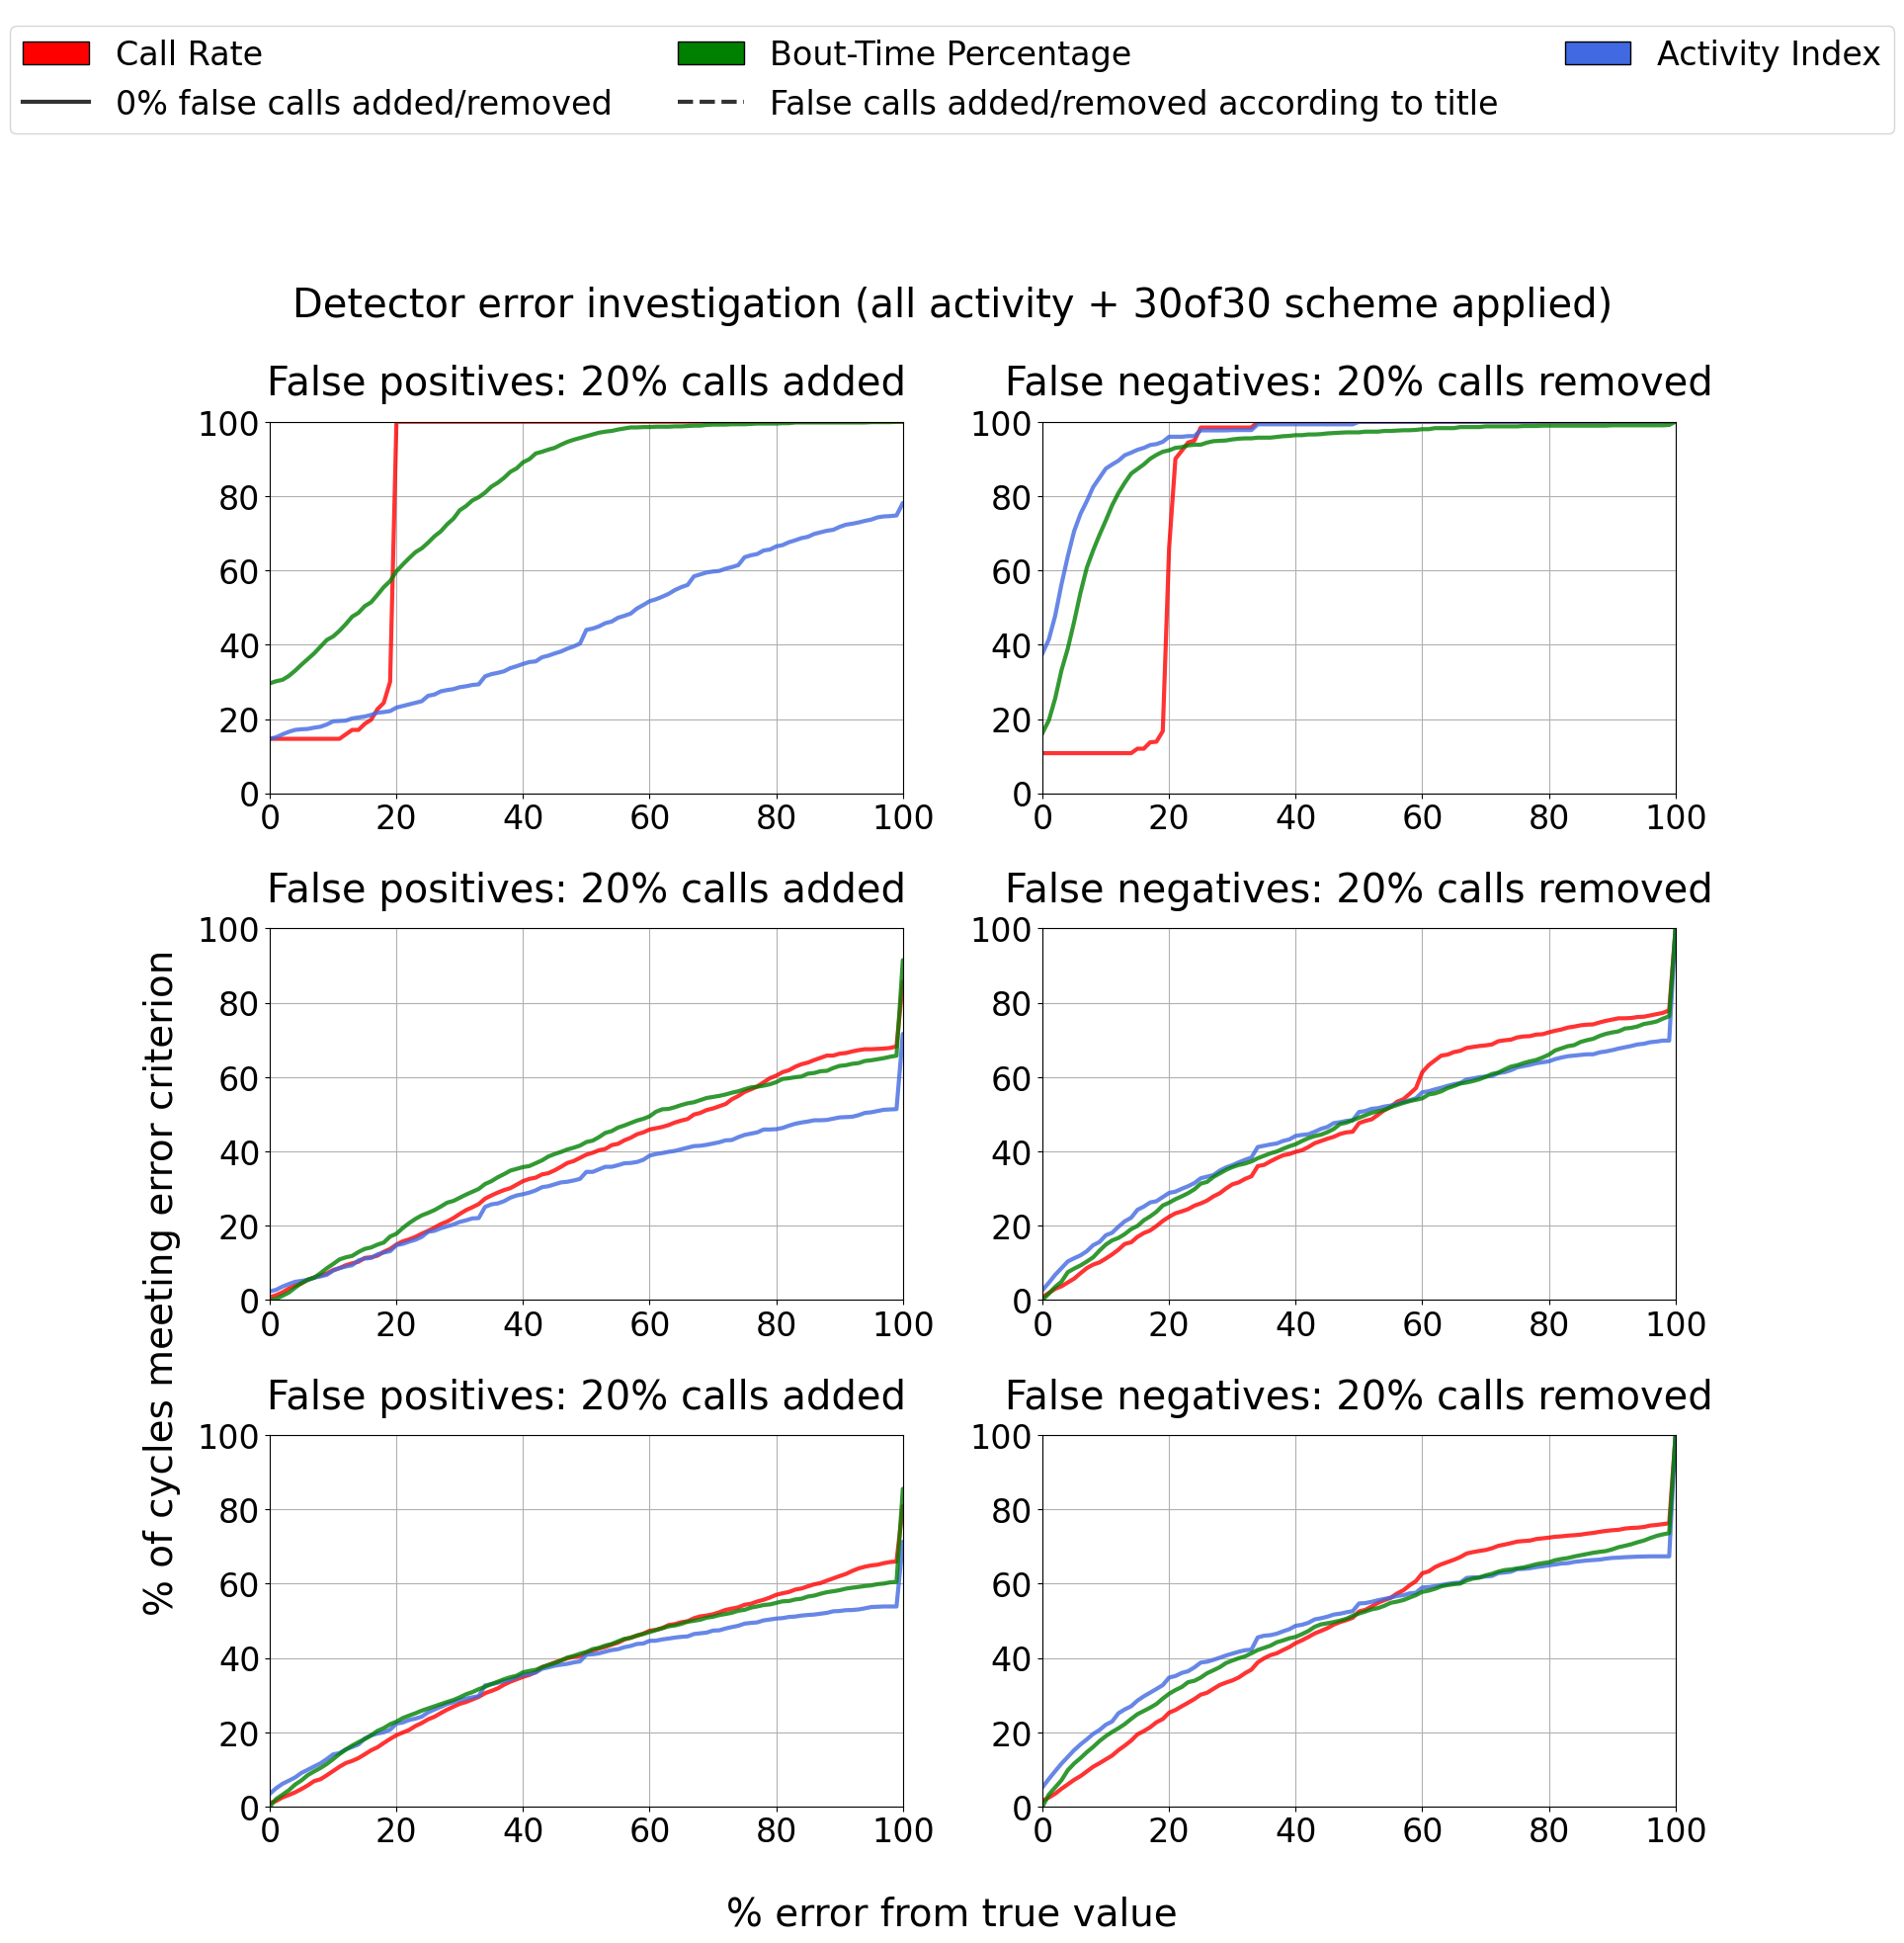

In [15]:
activity_level = 'all'
dc_tag = '30of30'
cycle_length = (dc_tag.split('of')[-1])
cont_tag = f'{cycle_length}of{cycle_length}'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

fig, ax = plt.subplots(3, 2, figsize=(16, 16.5), constrained_layout=True)
plt.rcParams.update({'font.size':24})
fig.suptitle(f'Detector error investigation (all activity + {dc_tag} scheme applied)')


i=0
frac = 0.2
plt_linestyle='solid'
cur_ax = ax[i,0]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False positives: {int(100*frac)}% calls added', y=1.05)
cur_ax.grid(which='both')

frac = 0.8
cur_ax = ax[i,1]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False negatives: {round(100*(1-frac))}% calls removed', y=1.05)
cur_ax.grid(which='both')

dc_tag = '15of30'
cycle_length = (dc_tag.split('of')[-1])
cont_tag = f'{cycle_length}of{cycle_length}'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

i=1
frac = 0.2
plt_linestyle='solid'
cur_ax = ax[i,0]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False positives: {int(100*frac)}% calls added', y=1.05)
cur_ax.grid(which='both')

frac = 0.8
cur_ax = ax[i,1]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False negatives: {round(100*(1-frac))}% calls removed', y=1.05)
cur_ax.grid(which='both')

dc_tag = '5of10'
cycle_length = (dc_tag.split('of')[-1])
cont_tag = f'{cycle_length}of{cycle_length}'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

i=2
frac = 0.2
plt_linestyle='solid'
cur_ax = ax[i,0]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False positives: {int(100*frac)}% calls added', y=1.05)
cur_ax.grid(which='both')

frac = 0.8
cur_ax = ax[i,1]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False negatives: {round(100*(1-frac))}% calls removed', y=1.05)
cur_ax.grid(which='both')


fig.text(0, 0.17, '% of cycles meeting error criterion', ha='center', rotation='vertical', fontsize=plt.rcParams['font.size']+4)
fig.text(0.5, -0.025, '% error from true value', ha='center', fontsize=plt.rcParams['font.size']+4)
fig.tight_layout()

# Create legend patches
CR_patch = patches.Patch(facecolor='red', edgecolor='k', label='Call Rate')
AI_patch = patches.Patch(facecolor='royalblue', edgecolor='k', label='Activity Index')
BTP_patch = patches.Patch(facecolor='green', edgecolor='k', label='Bout-Time Percentage')
line_high = Line2D([0], [0], linewidth=3, alpha=0.8, linestyle='solid', label='0% false calls added/removed', color='k')
line_low = Line2D([0], [0], linewidth=3, alpha=0.8, linestyle='dashed', label='False calls added/removed according to title', color='k')
legend_patches = [CR_patch, line_high, BTP_patch, line_low, AI_patch]

# Add legend
legend_ax = fig.add_axes([0.0, 0.0, 1.0, 1.15])
legend_ax.axis('off')
legend_ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size'], ncol=3, loc='upper center')

plt.show()

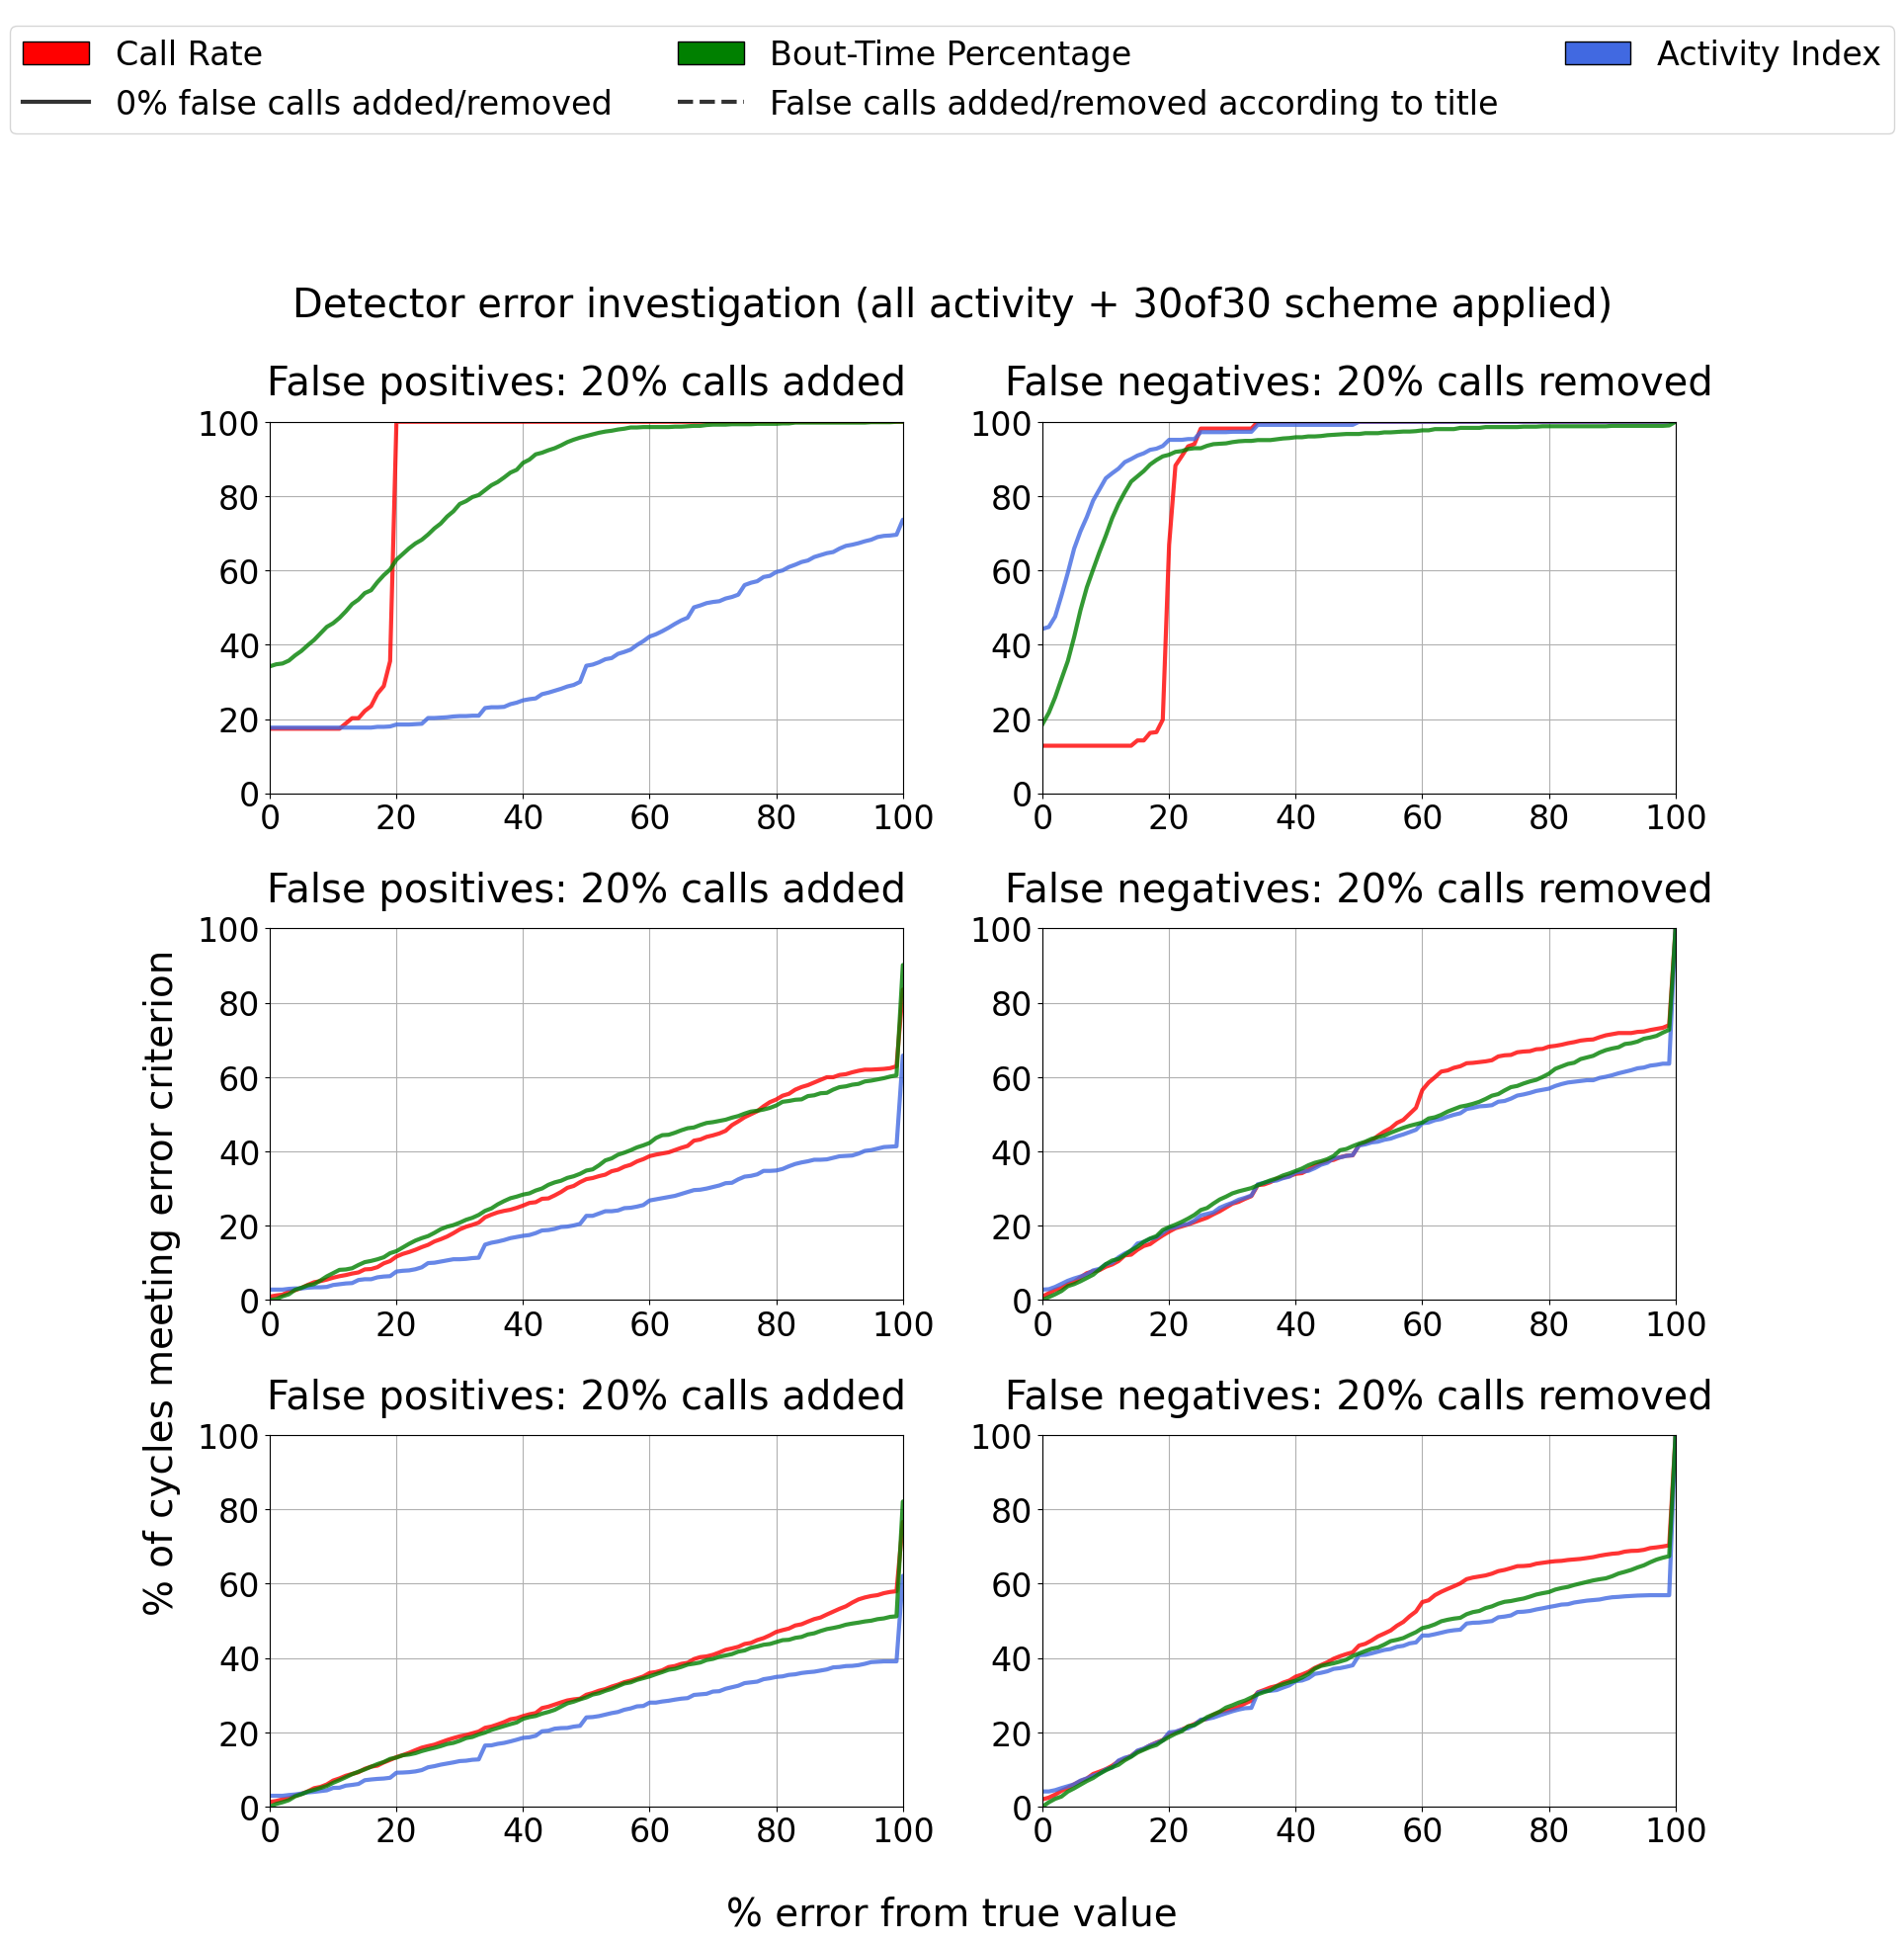

In [16]:
activity_level = 'low'
dc_tag = '30of30'
cycle_length = (dc_tag.split('of')[-1])
cont_tag = f'{cycle_length}of{cycle_length}'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

fig, ax = plt.subplots(3, 2, figsize=(16, 16.5), constrained_layout=True)
plt.rcParams.update({'font.size':24})
fig.suptitle(f'Detector error investigation (all activity + {dc_tag} scheme applied)')


i=0
frac = 0.2
plt_linestyle='solid'
cur_ax = ax[i,0]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False positives: {int(100*frac)}% calls added', y=1.05)
cur_ax.grid(which='both')

frac = 0.8
cur_ax = ax[i,1]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False negatives: {round(100*(1-frac))}% calls removed', y=1.05)
cur_ax.grid(which='both')

dc_tag = '15of30'
cycle_length = (dc_tag.split('of')[-1])
cont_tag = f'{cycle_length}of{cycle_length}'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

i=1
frac = 0.2
plt_linestyle='solid'
cur_ax = ax[i,0]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False positives: {int(100*frac)}% calls added', y=1.05)
cur_ax.grid(which='both')

frac = 0.8
cur_ax = ax[i,1]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False negatives: {round(100*(1-frac))}% calls removed', y=1.05)
cur_ax.grid(which='both')

dc_tag = '5of10'
cycle_length = (dc_tag.split('of')[-1])
cont_tag = f'{cycle_length}of{cycle_length}'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fp.index = pd.DatetimeIndex(activitybout_arr_fp.index)
btp_arr_fp.index = pd.DatetimeIndex(btp_arr_fp.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fp.index = pd.DatetimeIndex(activitycallrate_arr_fp.index)
callrate_arr_fp.index = pd.DatetimeIndex(callrate_arr_fp.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fp = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fp.index = pd.DatetimeIndex(activityind_arr_fp.index)
actvtind_arr_fp.index = pd.DatetimeIndex(actvtind_arr_fp.index)

data_params['metric_tag'] = 'bout_time_percentage'
file_paths = get_file_paths(data_params)

activitybout_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv', index_col=0)
btp_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv', index_col=0)
activitybout_arr_fn.index = pd.DatetimeIndex(activitybout_arr_fn.index)
btp_arr_fn.index = pd.DatetimeIndex(btp_arr_fn.index)

data_params['metric_tag'] = 'call_rate'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
callrate_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv', index_col=0)
activitycallrate_arr_fn.index = pd.DatetimeIndex(activitycallrate_arr_fn.index)
callrate_arr_fn.index = pd.DatetimeIndex(callrate_arr_fn.index)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv', index_col=0)
actvtind_arr_fn = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv', index_col=0)
activityind_arr_fn.index = pd.DatetimeIndex(activityind_arr_fn.index)
actvtind_arr_fn.index = pd.DatetimeIndex(actvtind_arr_fn.index)

i=2
frac = 0.2
plt_linestyle='solid'
cur_ax = ax[i,0]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fp.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fp.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False positives: {int(100*frac)}% calls added', y=1.05)
cur_ax.grid(which='both')

frac = 0.8
cur_ax = ax[i,1]
data_params['metric_tag'] = 'call_rate'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,2)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitycallrate_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(callrate_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activityind_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(actvtind_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)

data_params['metric_tag'] = 'bout_time_percentage'
data_params['index_time_block_in_secs'] = 5
metric_col_name = f'{data_params["metric_tag"]} ({round(frac,1)})'
cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
metric_for_scheme = pd.DataFrame(activitybout_arr_fn.loc[:,metric_col_name].dropna())
cont_column = pd.DataFrame(btp_arr_fn.loc[:,cont_metric_col_name].dropna())
metric_for_scheme_for_comparison = get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)
plot_percent_within_bounds_curve_for_metric(cur_ax, plt_dcmetr, plt_cmetr, data_params, plt_linestyle, activity_level)
cur_ax.set_title(f'False negatives: {round(100*(1-frac))}% calls removed', y=1.05)
cur_ax.grid(which='both')


fig.text(0, 0.17, '% of cycles meeting error criterion', ha='center', rotation='vertical', fontsize=plt.rcParams['font.size']+4)
fig.text(0.5, -0.025, '% error from true value', ha='center', fontsize=plt.rcParams['font.size']+4)
fig.tight_layout()

# Create legend patches
CR_patch = patches.Patch(facecolor='red', edgecolor='k', label='Call Rate')
AI_patch = patches.Patch(facecolor='royalblue', edgecolor='k', label='Activity Index')
BTP_patch = patches.Patch(facecolor='green', edgecolor='k', label='Bout-Time Percentage')
line_high = Line2D([0], [0], linewidth=3, alpha=0.8, linestyle='solid', label='0% false calls added/removed', color='k')
line_low = Line2D([0], [0], linewidth=3, alpha=0.8, linestyle='dashed', label='False calls added/removed according to title', color='k')
legend_patches = [CR_patch, line_high, BTP_patch, line_low, AI_patch]

# Add legend
legend_ax = fig.add_axes([0.0, 0.0, 1.0, 1.15])
legend_ax.axis('off')
legend_ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size'], ncol=3, loc='upper center')

plt.show()